# Rice Leaf Disease Detection
## 1. Importing Required Libraries
In this project, we need different Python libraries for data analysis, image processing, visualization, and machine learning.
The following libraries are used:
- **NumPy**: Used for numerical calculations and handling image arrays.
- **Pandas**: Used for creating and analyzing tabular data.
- **Matplotlib**: Used for displaying images and creating plots.
- **Seaborn**: Used for statistical visualization.
- **PIL (Python Imaging Library)**: Used for opening and processing images.
- **OS**: Used for working with folders and file paths.

In [1]:
import os
import numpy as np
import pandas as pd

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

## 2. Loading the Dataset

The rice leaf disease dataset is stored in a folder named `Data`.

The dataset contains images of rice leaves affected by three different diseases:

- Bacterial leaf blight
- Brown spot
- Leaf smut

In [3]:
# Loading the dataset..
dataset_path= r"Data"

## 3. Identifying the Disease Classes
The dataset contains three folders, where each folder represents a different rice leaf disease.
The three disease classes are:
1. Bacterial leaf blight
2. Brown spot
3. Leaf smut

We will create separate paths for each disease folder
These paths will be used later to access and analyze the images belonging to each class.

In [4]:
# Defining the class for each disease 

bacterial_leaf_blight_path = os.path.join(
    dataset_path,
    "Bacterial leaf blight-20200814T055237Z-001"
)

brown_spot_path = os.path.join(
    dataset_path,
    "Brown spot-20200814T055208Z-001"
)

leaf_smut_path = os.path.join(dataset_path,"Leaf smut-20200814T055530Z-001")

print("Bacterial leaf blight path:", bacterial_leaf_blight_path)
print("Brown spot path:", brown_spot_path)
print("Leaf smut path:", leaf_smut_path)

Bacterial leaf blight path: Data\Bacterial leaf blight-20200814T055237Z-001
Brown spot path: Data\Brown spot-20200814T055208Z-001
Leaf smut path: Data\Leaf smut-20200814T055530Z-001


## 4. Counting Images in Each Disease Class
Before performing data analysis, it is important to understand how many images are available in each class.
We will count the images from three disease folders:
- Bacterial leaf blight
- Brown spot
- Leaf smut

This helps us to know dataset is balanced or imbalanced.

In [5]:
# Get the list of files in each disease folder
bacterial_leaf_blight_images = os.listdir(bacterial_leaf_blight_path)
brown_spot_images = os.listdir(brown_spot_path)
leaf_smut_images = os.listdir(leaf_smut_path)
# Counting the number of images in each class
print("Bacterial leaf blight:", len(bacterial_leaf_blight_images))
print("Brown spot:", len(brown_spot_images))
print("Leaf smut:", len(leaf_smut_images))

Bacterial leaf blight: 2
Brown spot: 2
Leaf smut: 2


## 4. Exploring the Dataset Folder Structure

The initial count shows only 2 items inside each disease folder.
This indicates that the images may be stored inside additional subfolders.
Therefore, we will inspect the contents of each disease folder to understand the actual structure of the dataset before counting the images.

In [6]:
# Checking the contents of each disease folder
print("Bacterial leaf blight:")
print(os.listdir(bacterial_leaf_blight_path))
print("\nBrown spot:")
print(os.listdir(brown_spot_path))
print("\nLeaf smut:")
print(os.listdir(leaf_smut_path))

Bacterial leaf blight:
['.ipynb_checkpoints', 'Bacterial leaf blight']

Brown spot:
['.ipynb_checkpoints', 'Brown spot']

Leaf smut:
['.ipynb_checkpoints', 'Leaf smut']


## 5. Accessing the Actual Image Folders
After examining the dataset structure, we found that each disease folder contains another folder with the actual disease name.
The image files are stored inside these inner folders.
Therefore, we will create paths to these inner folders so that we can access the actual rice leaf images.

In [7]:
# Paths to the folders containing the actual images
bacterial_leaf_blight_images_path = os.path.join(
    bacterial_leaf_blight_path,
    "Bacterial leaf blight"
)
brown_spot_images_path = os.path.join(brown_spot_path,"Brown spot")
leaf_smut_images_path = os.path.join(leaf_smut_path,"Leaf smut")
print("Image folders accessed successfully!")

Image folders accessed successfully!


In [8]:
print("Bacterial leaf blight:")
print(os.listdir(bacterial_leaf_blight_images_path))

print("\nBrown spot:")
print(os.listdir(brown_spot_images_path))

print("\nLeaf smut:")
print(os.listdir(leaf_smut_images_path))

Bacterial leaf blight:
['DSC_0365.JPG', 'DSC_0366.jpg', 'DSC_0367.JPG', 'DSC_0370.jpg', 'DSC_0372.JPG', 'DSC_0373.JPG', 'DSC_0374.JPG', 'DSC_0375.JPG', 'DSC_0376.JPG', 'DSC_0377.JPG', 'DSC_0378.JPG', 'DSC_0379.JPG', 'DSC_0380.JPG', 'DSC_0381.JPG', 'DSC_0382.JPG', 'DSC_0383.JPG', 'DSC_0384.JPG', 'DSC_0385.jpg', 'DSC_0386.JPG', 'DSC_0388.JPG', 'DSC_0389.JPG', 'DSC_0390.JPG', 'DSC_0392.JPG', 'DSC_0393.JPG', 'DSC_0395.JPG', 'DSC_0396.JPG', 'DSC_0397.JPG', 'DSC_0398.JPG', 'DSC_0399.JPG', 'DSC_0400.JPG', 'DSC_0401.JPG', 'DSC_0402.JPG', 'DSC_0403.JPG', 'DSC_0404.JPG', 'DSC_0405.JPG', 'DSC_0406.JPG', 'DSC_0700.jpg', 'DSC_0701.jpg', 'DSC_0702.jpg', 'DSC_0703.JPG']

Brown spot:
['DSC_0100.jpg', 'DSC_0101.jpg', 'DSC_0104.jpg', 'DSC_0105.jpg', 'DSC_0106.jpg', 'DSC_0107.jpg', 'DSC_0108.jpg', 'DSC_0109.jpg', 'DSC_0110.jpg', 'DSC_0111.jpg', 'DSC_0112.jpg', 'DSC_0113.jpg', 'DSC_0114.jpg', 'DSC_0115.jpg', 'DSC_0116.jpg', 'DSC_0117.jpg', 'DSC_0118.jpg', 'DSC_0119.jpg', 'DSC_0121.jpg', 'DSC_0292.JPG', 'D

## 6. Counting Images in Each Disease Class

Now that we have identified the folders containing the actual images, we will count the number of image files in each disease class.

We will consider files with the following image extensions:

- `.jpg`
- `.jpeg`
- `.JPG`
- `.JPEG`

This will help us determine the total number of images and check whether the dataset is balanced.

In [9]:
# Counting image files in each disease class

bacterial_leaf_blight_count = len([
    file for file in os.listdir(bacterial_leaf_blight_images_path)
    if file.lower().endswith((".jpg", ".jpeg"))
])

brown_spot_count = len([file for file in os.listdir(brown_spot_images_path)
    if file.lower().endswith((".jpg", ".jpeg"))])

leaf_smut_count = len([
    file for file in os.listdir(leaf_smut_images_path)
    if file.lower().endswith((".jpg", ".jpeg"))
])

# Display the number of images

print("Bacterial leaf blight:", bacterial_leaf_blight_count)
print("Brown spot:", brown_spot_count)
print("Leaf smut:", leaf_smut_count)

Bacterial leaf blight: 40
Brown spot: 40
Leaf smut: 39


In [10]:
# Calculate the total number of images
total_images = (
    bacterial_leaf_blight_count
    + brown_spot_count
    + leaf_smut_count
)
print("Total number of images:", total_images)

Total number of images: 119


### Observation

The dataset contains a total of 119 images.

## 6. Verifying the Number of Images

The project description states that there are 40 images in each disease class. However, the actual dataset should be verified before performing the analysis.

We will count only the JPG and JPEG files in each class and calculate the total number of images.

In [11]:
# Count only JPG and JPEG files
bacterial_files = [
    file for file in os.listdir(bacterial_leaf_blight_images_path)
    if file.lower().endswith((".jpg", ".jpeg"))]
brown_files = [
    file for file in os.listdir(brown_spot_images_path)
    if file.lower().endswith((".jpg", ".jpeg"))
]
smut_files = [
    file for file in os.listdir(leaf_smut_images_path)
    if file.lower().endswith((".jpg", ".jpeg"))
]
# Display counts
print("Bacterial leaf blight:", len(bacterial_files))
print("Brown spot:", len(brown_files))
print("Leaf smut:", len(smut_files))

total_images = len(bacterial_files) + len(brown_files) + len(smut_files)

print("Total images:", total_images)

Bacterial leaf blight: 40
Brown spot: 40
Leaf smut: 39
Total images: 119


## 7. Verifying the Leaf Smut Images

The Leaf smut class contains 39 images according to our count, while the project description mentions 40 images.

We will inspect the Leaf smut folder to verify the number of image files present in the actual dataset.

In [12]:
# Display all Leaf smut image files

for i, file in enumerate(smut_files, start=1):
    print(i, file)

print("\nTotal Leaf smut images:", len(smut_files))

1 DSC_0293.JPG
2 DSC_0308.JPG
3 DSC_0309.JPG
4 DSC_0310.JPG
5 DSC_0312.JPG
6 DSC_0313.JPG
7 DSC_0314.JPG
8 DSC_0315.jpg
9 DSC_0316.JPG
10 DSC_0317.JPG
11 DSC_0318.JPG
12 DSC_0319.jpg
13 DSC_0320.JPG
14 DSC_0321.JPG
15 DSC_0322.jpg
16 DSC_0327.JPG
17 DSC_0328.jpg
18 DSC_0330.jpg
19 DSC_0331.JPG
20 DSC_0335.JPG
21 DSC_0336.jpg
22 DSC_0338.JPG
23 DSC_0339.jpg
24 DSC_0500.jpg
25 DSC_0501.jpg
26 DSC_0502.jpg
27 DSC_0503.jpg
28 DSC_0504.jpg
29 DSC_0505.jpg
30 DSC_0506.jpg
31 DSC_0507.jpg
32 DSC_0509.jpg
33 DSC_0510.jpg
34 DSC_0511.jpg
35 DSC_0512.jpg
36 DSC_0513.jpg
37 DSC_0514.jpg
38 DSC_0515.jpg
39 DSC_0516.jpg

Total Leaf smut images: 39


## 7. Dataset Summary

After inspecting the dataset, we found that the dataset contains three disease classes.

The number of images in each class is:

- Bacterial leaf blight: 40 images
- Brown spot: 40 images
- Leaf smut: 39 images

Therefore, the actual dataset contains 119 images.

Although the original project description mentions 120 images, our analysis will be based on the actual images available in the downloaded dataset.

In [13]:
# Create a summary of the dataset
class_names = ["Bacterial leaf blight","Brown spot","Leaf smut"]
image_counts = [bacterial_leaf_blight_count,brown_spot_count,leaf_smut_count]
dataset_summary = pd.DataFrame({"Disease": class_names,"Number of Images": image_counts})

In [14]:
dataset_summary

,Disease,Number of Images
0,Bacterial leaf blight,40
1,Brown spot,40
2,Leaf smut,39


### Observation

The dataset contains 119 images across three disease classes. Bacterial leaf blight and Brown spot contain 40 images each, while Leaf smut contains 39 images.

The difference of one image is very small, so the dataset can be considered approximately balanced.

## 8. Class Distribution

Class distribution shows the number of images available for each disease class.

A bar chart is used to visualize the distribution of images across the three classes. This helps us determine whether the dataset is balanced or imbalanced.

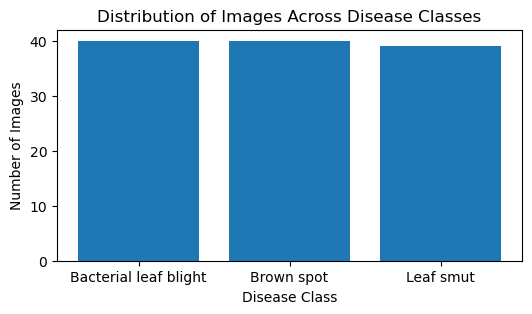

In [15]:
# Plot the number of images in each disease class
plt.figure(figsize=(6, 3))
plt.bar(dataset_summary["Disease"],dataset_summary["Number of Images"])
plt.title("Distribution of Images Across Disease Classes")
plt.xlabel("Disease Class")
plt.ylabel("Number of Images")
plt.show()

### Observation

The bar chart shows that the three disease classes have almost the same number of images.

- Bacterial leaf blight: 40 images
- Brown spot: 40 images
- Leaf smut: 39 images

Therefore, the dataset is approximately balanced, and there is no significant class imbalance.

## 9. Visualizing Sample Images

In this step, we will display sample images from each disease class.

Visual inspection helps us understand:

- The appearance of healthy and diseased leaf regions
- The color and texture of disease symptoms
- Differences between the three disease classes
- Whether the images have different backgrounds, orientations, or lighting conditions

This is an important step in exploratory data analysis before building the classification model.

(np.float64(-0.5), np.float64(3080.5), np.float64(896.5), np.float64(-0.5))

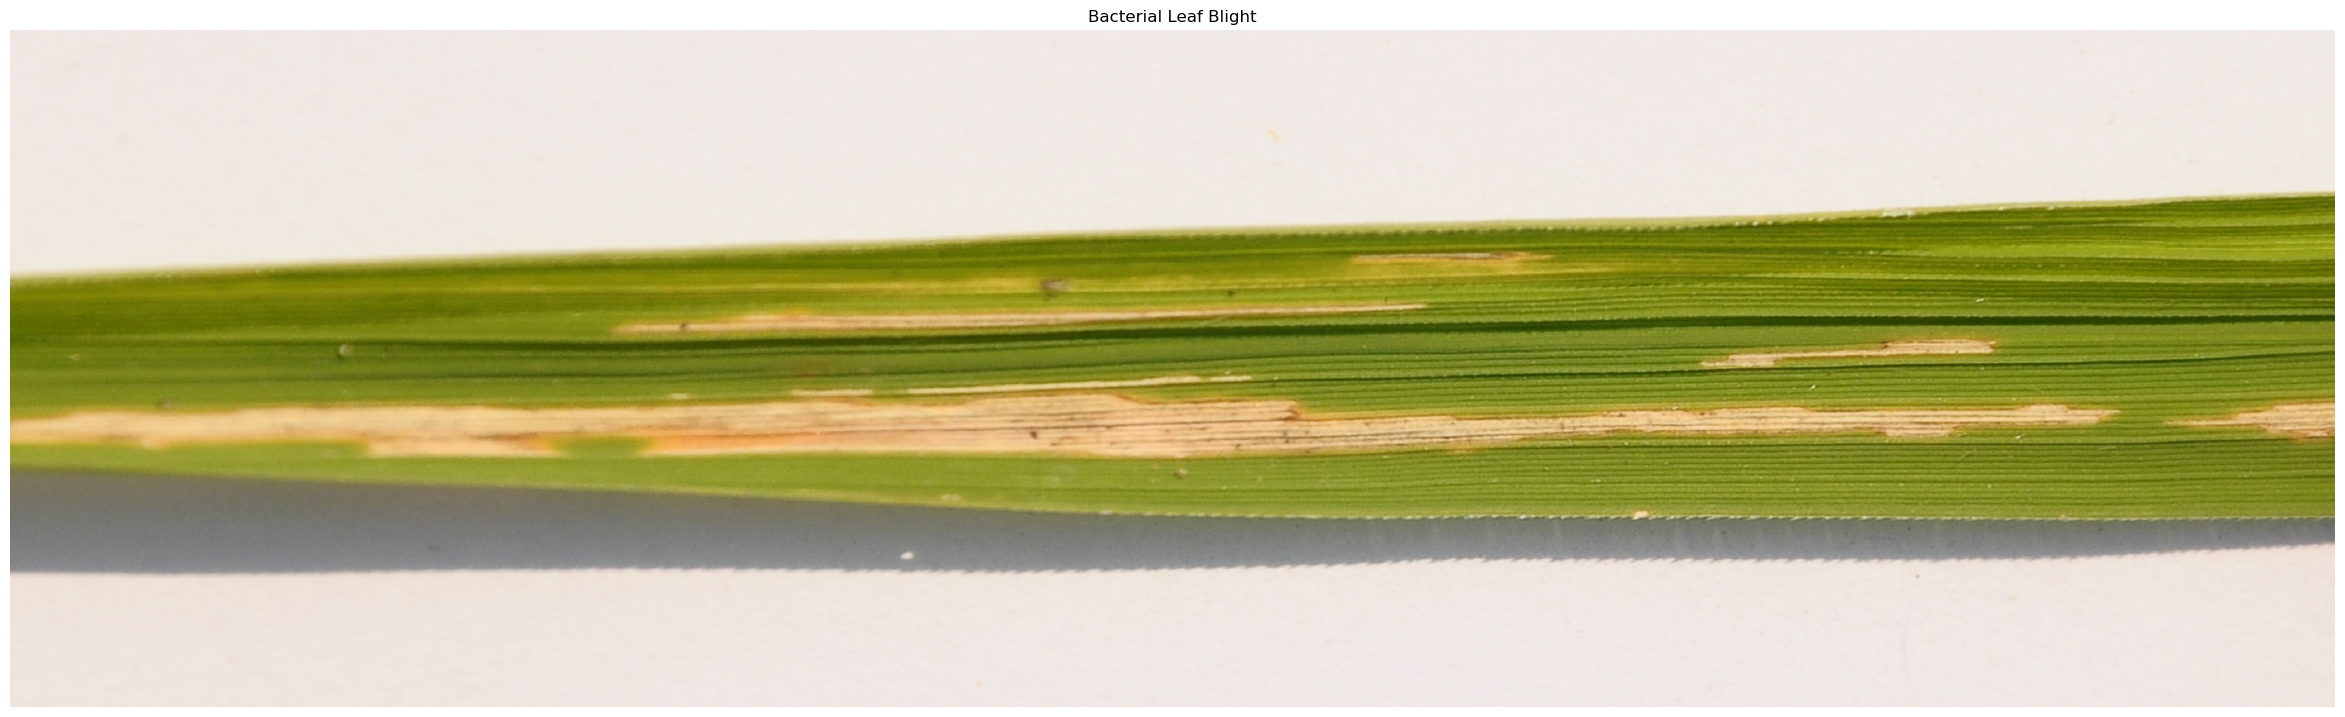

In [16]:
# Display one sample image from each disease class
plt.figure(figsize=(30,15))
# Bacterial leaf blight
image = Image.open(os.path.join(bacterial_leaf_blight_images_path, bacterial_files[4]))
plt.imshow(image)
plt.title("Bacterial Leaf Blight")
plt.axis("off")

(np.float64(-0.5), np.float64(1503.5), np.float64(322.5), np.float64(-0.5))

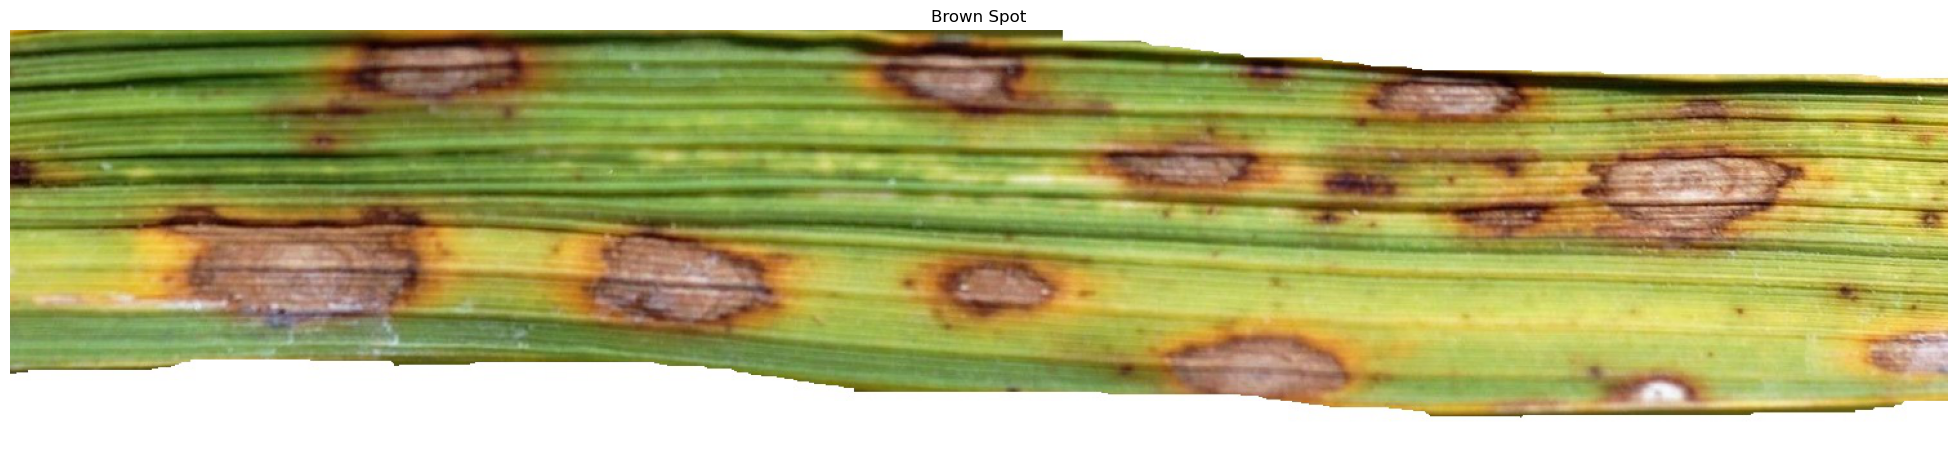

In [17]:
# Brown spot
plt.figure(figsize=(25,15))
image = Image.open(os.path.join(brown_spot_images_path, brown_files[4]))
plt.imshow(image)
plt.title("Brown Spot")
plt.axis("off")

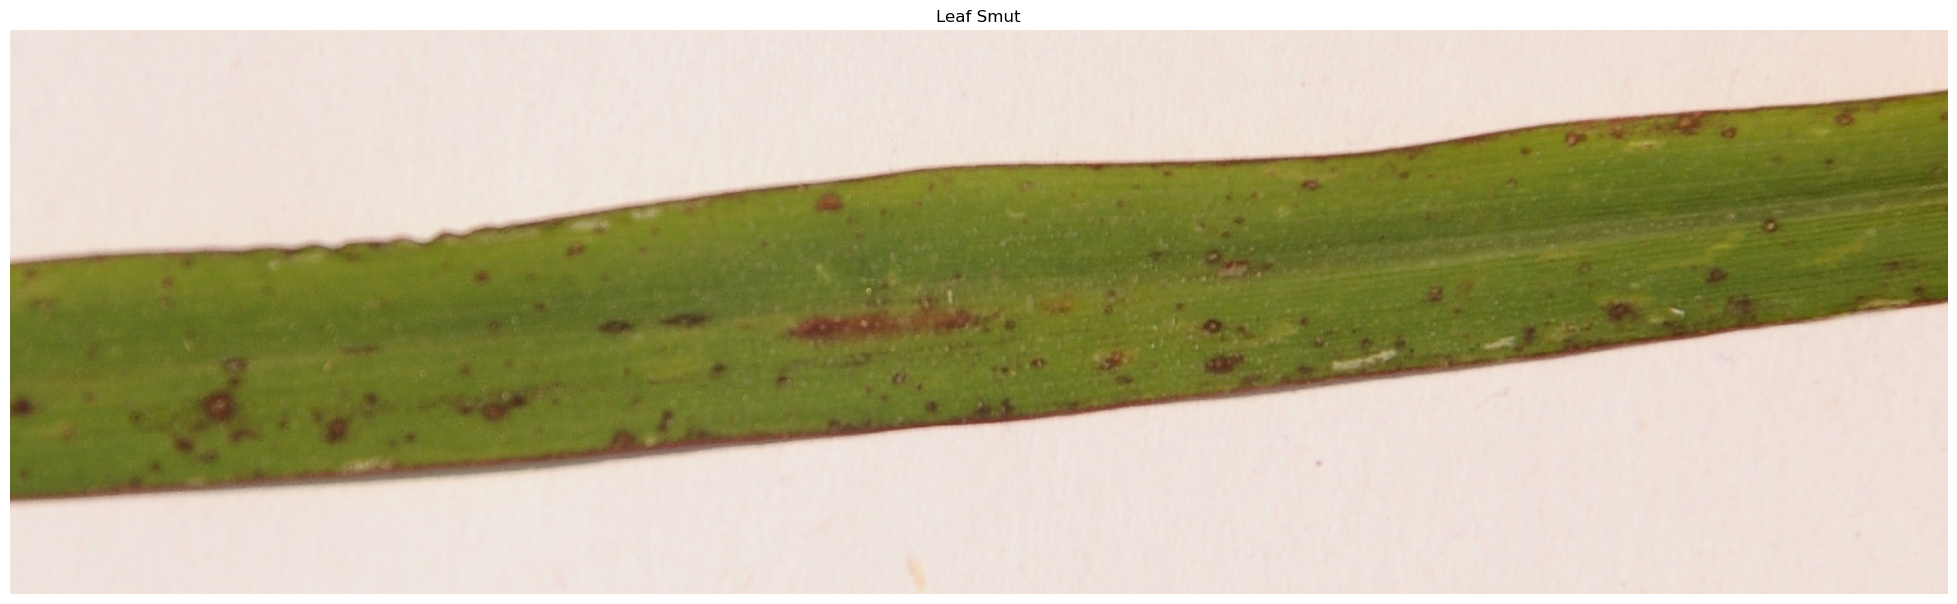

In [18]:
# Leaf smut
plt.figure(figsize=(25,15))
image = Image.open(os.path.join(leaf_smut_images_path, smut_files[2]))
plt.imshow(image)
plt.title("Leaf Smut")
plt.axis("off")
plt.show()

### Observation

The sample images show visible differences in the appearance of rice leaves affected by the three diseases.

The diseases may differ in terms of:

- Color of infected regions
- Shape and size of spots
- Distribution of disease symptoms
- Texture of the leaf

However, some visual characteristics may overlap between classes. Therefore, a deep learning model is required to learn the relevant features automatically.

## 10. Visualizing Multiple Images from Each Class

A single image may not represent the complete variation within a disease class.

Therefore, we will display multiple images from each class. This allows us to observe differences in:

- Leaf shape
- Disease patterns
- Color
- Background
- Image orientation
- Lighting conditions

This helps us understand the variability present in the dataset before model development.

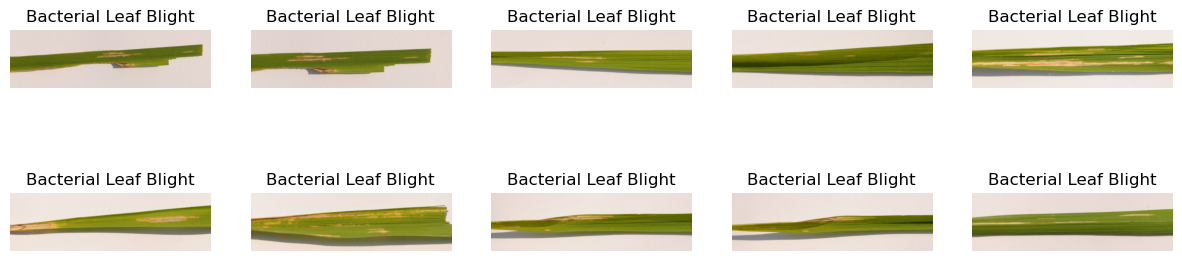

In [19]:
# Number of images to display from each class
num_images = 10
plt.figure(figsize=(15, 6))
# Bacterial leaf blight
for i in range(num_images):
    image = Image.open(os.path.join(bacterial_leaf_blight_images_path,bacterial_files[i]))

    plt.subplot(3, 5, i + 1)
    plt.imshow(image)
    plt.title("Bacterial Leaf Blight")
    plt.axis("off")

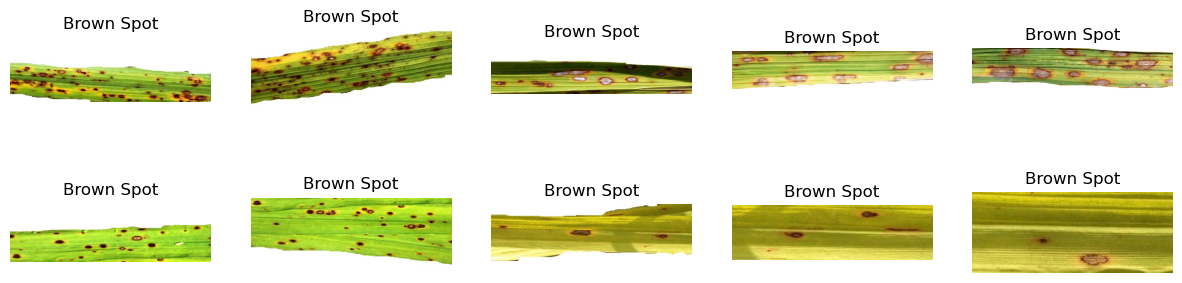

In [20]:
# Brown spot
plt.figure(figsize=(15,6))
for i in range(num_images):
    image = Image.open(os.path.join(brown_spot_images_path,brown_files[i]))
    plt.subplot(3, 5, i + 6)
    plt.imshow(image)
    plt.title("Brown Spot")
    plt.axis("off")

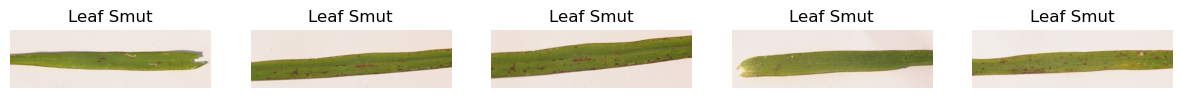

In [21]:
# Leaf smut
plt.figure(figsize=(15,6))
for i in range(5):
    image = Image.open(os.path.join(leaf_smut_images_path,smut_files[i]))
    plt.subplot(3, 5, i + 11)
    plt.imshow(image)
    plt.title("Leaf Smut")
    plt.axis("off")

### Observation

Multiple images from each class show that there is variation within the dataset.

The images differ in terms of leaf appearance, disease patterns, orientation, background, and lighting.

This variation is important because the model needs to learn disease-related features rather than memorizing a particular image.

The visualization also shows why techniques such as image preprocessing and data augmentation may be useful for improving model generalization.

## 11. Analyzing Image Dimensions

Images in the dataset may have different widths and heights.

Before training a deep learning model, images need to be resized to a common dimension.

In this step, we will examine the dimensions of the images to understand the variation in image sizes.

In [22]:
# Check the dimensions of images from each class
image_dimensions = []

In [23]:
# Bacterial leaf blight
for file in bacterial_files:
    image = Image.open(os.path.join(bacterial_leaf_blight_images_path, file))
    image_dimensions.append(image.size)

In [24]:
# Brown spot
for file in brown_files:
    image = Image.open(os.path.join(brown_spot_images_path, file))
    image_dimensions.append(image.size)

In [25]:
# Leaf smut
for file in smut_files:
    image = Image.open(os.path.join(leaf_smut_images_path, file))
    image_dimensions.append(image.size)

In [26]:
# Display unique image dimensions
unique_dimensions = set(image_dimensions)
print("Number of unique image dimensions:", len(unique_dimensions))
print("Image dimensions:")
for dimension in unique_dimensions:
    print(dimension)

Number of unique image dimensions: 34
Image dimensions:
(537, 216)
(503, 174)
(367, 73)
(562, 217)
(763, 268)
(946, 255)
(768, 514)
(427, 193)
(617, 244)
(296, 88)
(340, 94)
(316, 127)
(699, 197)
(467, 104)
(1200, 900)
(510, 383)
(1504, 323)
(286, 92)
(311, 170)
(948, 233)
(359, 168)
(766, 250)
(765, 224)
(250, 200)
(565, 233)
(614, 409)
(741, 291)
(301, 71)
(456, 124)
(376, 80)
(1480, 279)
(948, 211)
(3081, 897)
(1530, 371)


## 11. Analyzing Image Dimensions

Image dimensions represent the width and height of an image in pixels.

Images in a dataset may have different dimensions. Before providing images to a deep learning model, they need to be converted to a common size.

In this step, we will identify the different image dimensions present in the dataset.

In [27]:
# Store the dimensions of all images
image_dimensions = []

In [28]:
# Bacterial leaf blight
for file in bacterial_files:
    image = Image.open(os.path.join(bacterial_leaf_blight_images_path, file))
    image_dimensions.append(image.size)

In [29]:
# Leaf smut
for file in smut_files:
    image = Image.open(os.path.join(leaf_smut_images_path, file))
    image_dimensions.append(image.size)

In [30]:
# Brown spot
for file in brown_files:
    image = Image.open(os.path.join(brown_spot_images_path, file))
    image_dimensions.append(image.size)

In [31]:
# Find unique dimensions
unique_dimensions = set(image_dimensions)
print("Total images:", len(image_dimensions))
print("Number of unique dimensions:", len(unique_dimensions))
print("\nImage dimensions:")
for dimension in unique_dimensions:
    print(dimension)

Total images: 119
Number of unique dimensions: 34

Image dimensions:
(537, 216)
(503, 174)
(367, 73)
(562, 217)
(763, 268)
(946, 255)
(768, 514)
(427, 193)
(617, 244)
(296, 88)
(316, 127)
(340, 94)
(699, 197)
(467, 104)
(510, 383)
(1200, 900)
(1504, 323)
(948, 233)
(286, 92)
(311, 170)
(359, 168)
(766, 250)
(741, 291)
(565, 233)
(250, 200)
(614, 409)
(765, 224)
(301, 71)
(376, 80)
(456, 124)
(1480, 279)
(948, 211)
(3081, 897)
(1530, 371)


## 12. Checking Image Formats
The dataset contains image files with different extensions such as `.jpg` and `.JPG`.
We will check the image formats available in the dataset. This helps us verify that the files are valid image files and understand the file formats used in the dataset.

In [32]:
# Get the file extensions of all images
image_extensions = []
for file in bacterial_files:
    image_extensions.append(os.path.splitext(file)[1].lower())
for file in brown_files:
    image_extensions.append(os.path.splitext(file)[1].lower())

for file in smut_files:
    image_extensions.append(os.path.splitext(file)[1].lower())

In [33]:
# Count each image format
extension_counts = pd.Series(image_extensions).value_counts()
print(extension_counts)

.jpg    119
Name: count, dtype: int64


## 13. Checking for Corrupted Images
A corrupted or damaged image may cause errors when loading or training the model.
Therefore, we will verify every image in the dataset by attempting to open it using the PIL library.
If an image cannot be opened, we will record it as a corrupted image.
This step helps ensure that the dataset is suitable for further analysis and model development.

In [34]:
# Store all image paths
all_image_paths = []

In [35]:
for file in bacterial_files:
    all_image_paths.append(os.path.join(bacterial_leaf_blight_images_path, file))

In [36]:
for file in brown_files:
    all_image_paths.append(os.path.join(brown_spot_images_path, file))

In [37]:
for file in smut_files:
    all_image_paths.append(os.path.join(leaf_smut_images_path, file))

In [38]:
# Check each image
corrupted_images = []

In [39]:
for image_path in all_image_paths:
    try:
        image = Image.open(image_path)
        image.verify()
    except Exception:
        corrupted_images.append(image_path)

In [40]:
# Display results
print("Total images checked:", len(all_image_paths))
print("Corrupted images:", len(corrupted_images))
if len(corrupted_images) > 0:
    print("\nCorrupted image files:")
    for image in corrupted_images:
        print(image)
else:
    print("No corrupted images found.")

Total images checked: 119
Corrupted images: 0
No corrupted images found.


### Observation
All 119 images were successfully checked using the PIL library.
No corrupted images were found in the dataset. Therefore, all the available images can be used for further preprocessing and model development.

## 14. Analyzing Image Color Channels
Digital images can contain different numbers of color channels.
A typical color image contains three channels:
- Red (R)
- Green (G)
- Blue (B)
In this step, we will check the image mode of the dataset to determine whether the images are RGB, grayscale, or another format.

In [41]:
# Check the image modes

image_modes = []
for image_path in all_image_paths:
    image = Image.open(image_path)
    image_modes.append(image.mode)

In [42]:
# Count the different image modes

mode_counts = pd.Series(image_modes).value_counts()
print(mode_counts)

RGB    119
Name: count, dtype: int64


### Observation
All 119 images in the dataset are in RGB format.
RGB images contain three color channels:
- Red
- Green
- Blue
Therefore, no grayscale or other image formats were found. Since the images are RGB, they can be directly used as color images during preprocessing and model development.

## 15. Analyzing Image Size Statistics
Images in the dataset may have different widths and heights.
We will calculate the minimum, maximum, and average width and height of the images. This gives us a better understanding of the variation in image sizes.
This information will help us decide an appropriate image size for training the deep learning models.

In [43]:
# Separate width and height from the image dimensions

widths = [dimension[0] for dimension in image_dimensions]
heights = [dimension[1] for dimension in image_dimensions]

In [44]:
# Calculate statistics

print("Minimum width:", min(widths))
print("Maximum width:", max(widths))
print("Average width:", sum(widths) / len(widths))

print("\nMinimum height:", min(heights))
print("Maximum height:", max(heights))
print("Average height:", sum(heights) / len(heights))

Minimum width: 250
Maximum width: 3081
Average width: 2383.638655462185

Minimum height: 71
Maximum height: 900
Average height: 707.7394957983194


### Observation

The image dimensions vary considerably across the dataset.

The width ranges from 250 to 3081 pixels, with an average width of approximately 2384 pixels.

The height ranges from 71 to 900 pixels, with an average height of approximately 708 pixels.

This shows that the images do not have a consistent size. Therefore, resizing will be necessary during preprocessing before feeding the images into the deep learning models.

## 16. Analyzing Image Aspect Ratios

Aspect ratio represents the relationship between the width and height of an image.

It is calculated by dividing the width of an image by its height.

Analyzing aspect ratios helps us understand whether the images have similar shapes or whether they have significant variations in shape.

This is important because resizing images with very different aspect ratios can distort the appearance of the rice leaves.

In [45]:
# Calculate aspect ratios

aspect_ratios = []

for width, height in image_dimensions:
    aspect_ratio = width / height
    aspect_ratios.append(aspect_ratio)
print("Minimum aspect ratio:", min(aspect_ratios))
print("Maximum aspect ratio:", max(aspect_ratios))
print("Average aspect ratio:", sum(aspect_ratios) / len(aspect_ratios))

Minimum aspect ratio: 1.25
Maximum aspect ratio: 5.304659498207886
Average aspect ratio: 3.3252545609838715


### Observation

The aspect ratios of the images vary significantly across the dataset.

- Minimum aspect ratio: 1.25
- Maximum aspect ratio: 5.30
- Average aspect ratio: 3.33

This indicates that the images are mostly wider than they are tall and do not have a uniform shape.

Therefore, image resizing should be handled carefully during preprocessing to avoid excessive distortion of the rice leaf features.

## 17. Visualizing Aspect Ratio Distribution

A histogram is used to visualize the distribution of aspect ratios across all images.

This helps us understand whether most images have similar shapes or whether the dataset contains a wide range of aspect ratios.

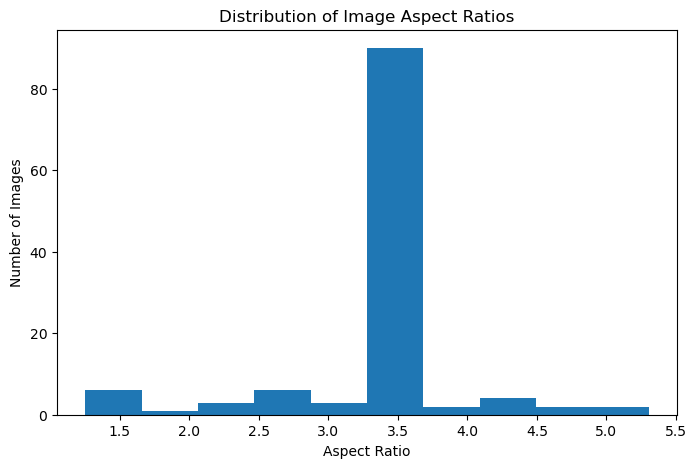

In [46]:
# Plot the distribution of aspect ratios

plt.figure(figsize=(8, 5))

plt.hist(aspect_ratios, bins=10)

plt.xlabel("Aspect Ratio")
plt.ylabel("Number of Images")
plt.title("Distribution of Image Aspect Ratios")

plt.show()

## 18. Analyzing Pixel Values

A digital image is made up of pixels. Each pixel contains numerical values that represent its color.

Since our images are RGB images, each pixel contains three values:

- Red
- Green
- Blue

For standard RGB images, pixel values generally range from 0 to 255.

In this step, we will examine the minimum and maximum pixel values in the dataset.

In [47]:
# Store pixel values from all images

pixel_values = []

for image_path in all_image_paths:
    image = Image.open(image_path).convert("RGB")
    image_array = np.array(image)
    pixel_values.append(image_array)

In [48]:
# Find minimum and maximum pixel values

print("Minimum pixel value:", min(image.min() for image in pixel_values))
print("Maximum pixel value:", max(image.max() for image in pixel_values))

Minimum pixel value: 0
Maximum pixel value: 255


## 19. Visualizing an Image and Its Pixel Values

An image is represented in Python as a NumPy array.

For an RGB image, the array has three dimensions:

- Height
- Width
- Color channels

The three color channels represent Red, Green, and Blue.

We will display one sample image and inspect its NumPy array shape and pixel values.

In [49]:
# Load one sample image

sample_image_path = all_image_paths[0]
sample_image = Image.open(sample_image_path).convert("RGB")

In [50]:
# Convert the image into a NumPy array
sample_array = np.array(sample_image)

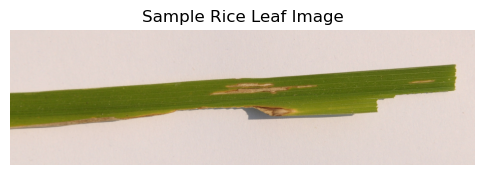

In [51]:
# Display the image
plt.figure(figsize=(6, 5))
plt.imshow(sample_array)
plt.title("Sample Rice Leaf Image")
plt.axis("off")
plt.show()

In [52]:
# Display image information
print("Image shape:", sample_array.shape)
print("Minimum pixel value:", sample_array.min())
print("Maximum pixel value:", sample_array.max())

Image shape: (897, 3081, 3)
Minimum pixel value: 0
Maximum pixel value: 246


### Observation
The image is represented as a three-dimensional NumPy array.
The first two dimensions represent the height and width of the image, while the third dimension represents the three RGB color channels.
The pixel values range from 0 to 255. These values will later be normalized before training the deep learning models.

## 20. Analyzing Color Distribution

Color is an important characteristic of rice leaf images because disease symptoms can appear as changes in leaf color.

For RGB images, each pixel contains three color values:

- Red (R)
- Green (G)
- Blue (B)

We will calculate the average value of each RGB channel for every image and then visualize the overall distribution.

This analysis helps us understand the general color characteristics of the dataset.

In [53]:
# Calculate average RGB values for each image

average_rgb = []

for image_path in all_image_paths:
    image = Image.open(image_path).convert("RGB")
    image_array = np.array(image)
    # Calculate average value for each channel
    mean_rgb = image_array.mean(axis=(0, 1))
    average_rgb.append(mean_rgb)
    # Calculate average value for each channel
    mean_rgb = image_array.mean(axis=(0, 1))
    average_rgb.append(mean_rgb)

In [54]:
# Convert to NumPy array
average_rgb = np.array(average_rgb)

In [55]:
print("Average Red value:", average_rgb[:, 0].mean())
print("Average Green value:", average_rgb[:, 1].mean())
print("Average Blue value:", average_rgb[:, 2].mean())

Average Red value: 188.60257438202675
Average Green value: 186.79597174384566
Average Blue value: 140.0704765819848


In [56]:
# Create a DataFrame for RGB analysis
rgb_data = pd.DataFrame(average_rgb,columns=["Red", "Green", "Blue"])
rgb_data.head()

,Red,Green,Blue
0,196.807981,187.391320,163.822809
1,196.807981,187.391320,163.822809
2,194.008195,185.150240,159.361242
3,194.008195,185.150240,159.361242
4,196.319661,189.777191,154.965337


C:\Users\Govardhan Goud\AppData\Local\Temp\ipykernel_488\3101705542.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([rgb_data["Red"],rgb_data["Green"],rgb_data["Blue"]],labels=["Red", "Green", "Blue"])


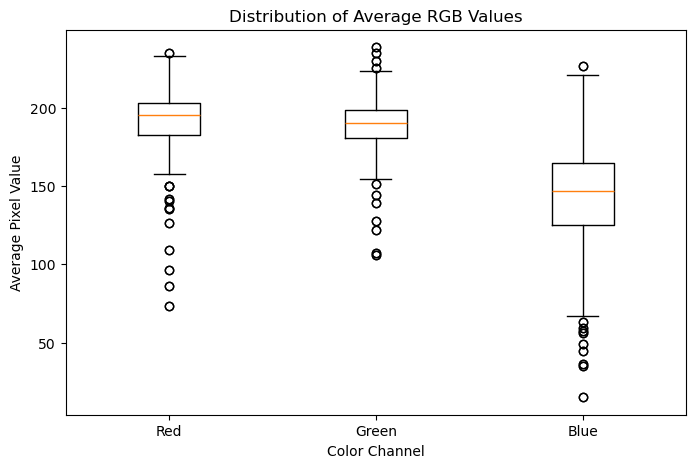

In [57]:
# Visualize the average RGB values

plt.figure(figsize=(8, 5))
plt.boxplot([rgb_data["Red"],rgb_data["Green"],rgb_data["Blue"]],labels=["Red", "Green", "Blue"])
plt.xlabel("Color Channel")
plt.ylabel("Average Pixel Value")
plt.title("Distribution of Average RGB Values")
plt.show()

# 21. Exploratory Data Analysis Summary

The rice leaf disease dataset was analyzed to understand its structure and characteristics before model development.

### Dataset Size

The actual dataset contains **119 images** belonging to three disease classes:

- Bacterial leaf blight: 40 images
- Brown spot: 40 images
- Leaf smut: 39 images

The dataset is approximately balanced because the difference between the largest and smallest classes is only one image.

### Image Format

All 119 images are RGB images. No grayscale images were found.

### Image Quality

All 119 images were successfully opened and verified. No corrupted images were detected.

### Image Dimensions

The image dimensions vary considerably:

- Minimum width: 250 pixels
- Maximum width: 3081 pixels
- Average width: approximately 2384 pixels
- Minimum height: 71 pixels
- Maximum height: 900 pixels
- Average height: approximately 708 pixels

Therefore, the images need to be resized to a common size before model training.

### Aspect Ratio

The aspect ratio also varies across the dataset:

- Minimum aspect ratio: 1.25
- Maximum aspect ratio: approximately 5.30
- Average aspect ratio: approximately 3.33

This indicates that the images have different shapes, so resizing should be performed carefully to minimize distortion.

### Overall Conclusion

The dataset is small, approximately balanced, and contains images with different dimensions and aspect ratios. The images are valid RGB images with no corrupted files.

Based on these findings, the next stage is image preprocessing, including resizing, normalization, and preparation of labels for model training.

## 22. Creating Image Paths and Labels

For supervised machine learning, each image must have a corresponding label.

We will create a list containing:

- The path of each image
- The disease class associated with that image

The three disease classes will be represented by their names:

- Bacterial leaf blight
- Brown spot
- Leaf smut

This information will later be used to train and evaluate the classification models.

In [58]:
# Create image paths and corresponding labels

image_paths = []
labels = []

In [59]:
# Bacterial leaf blight
for file in bacterial_files:
    image_paths.append(os.path.join(bacterial_leaf_blight_images_path, file))
    labels.append("Bacterial leaf blight")

In [60]:
# Brown spot
for file in brown_files:
    image_paths.append(os.path.join(brown_spot_images_path, file))
    labels.append("Brown spot")

In [61]:
# Leaf smut
for file in smut_files:
    image_paths.append(os.path.join(leaf_smut_images_path, file))
    labels.append("Leaf smut")

In [62]:
print("Total image paths:", len(image_paths))
print("Total labels:", len(labels))

Total image paths: 119
Total labels: 119


In [63]:
# Create a DataFrame containing image paths and labels

data = pd.DataFrame({"image_path": image_paths,"label": labels})
data.head()

,image_path,label
0,Data\Bacterial leaf blight-20200814T055237Z-00...,Bacterial leaf blight
1,Data\Bacterial leaf blight-20200814T055237Z-00...,Bacterial leaf blight
2,Data\Bacterial leaf blight-20200814T055237Z-00...,Bacterial leaf blight
3,Data\Bacterial leaf blight-20200814T055237Z-00...,Bacterial leaf blight
4,Data\Bacterial leaf blight-20200814T055237Z-00...,Bacterial leaf blight


### Observation

A DataFrame containing 119 image paths and their corresponding disease labels was successfully created.

Each image has exactly one associated disease label. This structured dataset will be used for splitting the data into training, validation, and testing sets.

## 23. Splitting the Dataset

The dataset needs to be divided into separate subsets for model development.

- **Training set:** Used to train the model.
- **Validation set:** Used to monitor the model during training and help tune model parameters.
- **Test set:** Used only at the end to evaluate the final model on unseen images.

We will use stratified splitting so that the three disease classes are represented proportionally in each subset.

The dataset will be divided approximately into:

- 70% training data
- 15% validation data
- 15% testing data

In [64]:
from sklearn.model_selection import train_test_split

In [65]:
# First spliting: 70% training and 30% temporary data
train_data, temp_data = train_test_split(
    data,
    test_size=0.30,
    stratify=data["label"],
    random_state=42)

In [66]:
# Second spliting: divide temporary data equally
val_data, test_data = train_test_split(
    temp_data,
    test_size=0.50,
    stratify=temp_data["label"],
    random_state=42)

In [67]:
print("Training images:", len(train_data))
print("Validation images:", len(val_data))
print("Testing images:", len(test_data))

Training images: 83
Validation images: 18
Testing images: 18


In [68]:
print("Training distribution:")
print(train_data["label"].value_counts())

print("\nValidation distribution:")
print(val_data["label"].value_counts())

print("\nTesting distribution:")
print(test_data["label"].value_counts())

Training distribution:
label
Brown spot               28
Bacterial leaf blight    28
Leaf smut                27
Name: count, dtype: int64

Validation distribution:
label
Leaf smut                6
Brown spot               6
Bacterial leaf blight    6
Name: count, dtype: int64

Testing distribution:
label
Leaf smut                6
Brown spot               6
Bacterial leaf blight    6
Name: count, dtype: int64


### Observation

The dataset was divided into training, validation, and testing sets using stratified sampling.

Stratification ensures that each disease class is represented in the subsets, reducing the possibility of an unbalanced split.

The test dataset will remain unseen during model training and will be used for the final model evaluation.

## 24. Setting the Image Size

The images in our dataset have different dimensions. Deep learning models require images with a fixed input size.

Therefore, all images will be resized to 224 × 224 pixels.

The 224 × 224 size is commonly used with pretrained convolutional neural networks such as VGG16, MobileNetV2, and EfficientNetB0.

Using the same image size also allows us to compare the performance of different models fairly.

In [69]:
# Define the image size

IMG_SIZE = (224, 224)
print("Target image size:", IMG_SIZE)

Target image size: (224, 224)


## 25. Creating Data Generators

A data generator loads images in batches instead of loading the entire dataset into memory at once.

We will use Keras ImageDataGenerator to:

- Resize images to 224 × 224 pixels
- Normalize pixel values from the range 0–255 to the range 0–1
- Generate batches of images during model training

At this stage, no data augmentation is applied. Data augmentation will be analyzed separately in the next step.

In [70]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [71]:
# Create data generators
train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)
print("Data generators created successfully!")

Data generators created successfully!


In [72]:
import shutil

In [73]:
base_dir = "rice_leaf_split"

In [74]:
train_dir = os.path.join(base_dir, "train")

In [75]:
val_dir = os.path.join(base_dir, "validation")

In [76]:
test_dir = os.path.join(base_dir, "test")

In [77]:
os.makedirs(train_dir, exist_ok=True)

In [78]:
os.makedirs(val_dir, exist_ok=True)

In [79]:
os.makedirs(test_dir, exist_ok=True)


In [80]:
# Create class folders inside train, validation and test

for class_name in class_names:
    os.makedirs(os.path.join(train_dir, class_name), exist_ok=True)
    os.makedirs(os.path.join(val_dir, class_name), exist_ok=True)
    os.makedirs(os.path.join(test_dir, class_name), exist_ok=True)

print("Class folders created successfully!")

Class folders created successfully!


In [81]:
# Copy training images

for _, row in train_data.iterrows():
    destination = os.path.join(
        train_dir,
        row["label"],
        os.path.basename(row["image_path"])
    )
    shutil.copy(row["image_path"], destination)


In [82]:
# Copy validation images

for _, row in val_data.iterrows():
    destination = os.path.join(
        val_dir,
        row["label"],
        os.path.basename(row["image_path"])
    )
    shutil.copy(row["image_path"], destination)


In [83]:
# Copy testing images

for _, row in test_data.iterrows():
    destination = os.path.join(
        test_dir,
        row["label"],
        os.path.basename(row["image_path"])
    )
    shutil.copy(row["image_path"], destination)

print("Images copied successfully!")

Images copied successfully!


In [84]:
# Create generators from the folders

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=16,
    class_mode="categorical",
    shuffle=True
)


Found 83 images belonging to 3 classes.


In [85]:
val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=16,
    class_mode="categorical",
    shuffle=False
)


Found 18 images belonging to 3 classes.


In [86]:
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=16,
    class_mode="categorical",
    shuffle=False
)

Found 18 images belonging to 3 classes.


### Observation

The images have been prepared using Keras data generators.

All images will be resized to 224 × 224 pixels and their pixel values will be normalized from 0–255 to 0–1.

The training, validation, and test datasets are kept separate to ensure that the test data remains unseen during model training.

## 26. Data Augmentation

The dataset contains only 119 images, which is relatively small for training a deep learning model.

Data augmentation is a technique used to artificially increase the variety of training images by applying transformations such as:

- Rotation
- Horizontal flipping
- Zooming
- Width and height shifting

These transformations create different versions of existing training images while preserving the disease class.

Data augmentation is applied only to the training data. Validation and test images are not augmented because they should represent unseen real-world data.

In [87]:
# Create a data generator with augmentation

augmented_train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

print("Data augmentation generator created successfully!")

Data augmentation generator created successfully!


## 27. Visualizing Data Augmentation

Data augmentation applies random transformations to the original training images.

In this step, we will generate multiple augmented versions of one rice leaf image and visualize them.

This allows us to verify that the transformations preserve the important disease features while creating useful variations in the training data.

In [88]:
# Select one image from the training dataset

sample_path = train_data.iloc[0]["image_path"]

print("Selected image:")
print(sample_path)

Selected image:
Data\Leaf smut-20200814T055530Z-001\Leaf smut\DSC_0514.jpg


In [89]:
# Load the selected image

sample_image = Image.open(sample_path).convert("RGB")

print("Original image size:", sample_image.size)

Original image size: (565, 233)


In [90]:
# Add batch dimension

sample_array = np.expand_dims(sample_array, axis=0)

# Generate augmented images

augmented_images = augmented_train_datagen.flow(
    sample_array,
    batch_size=1,
    shuffle=False
)

print("Augmented image generator created!")

Augmented image generator created!


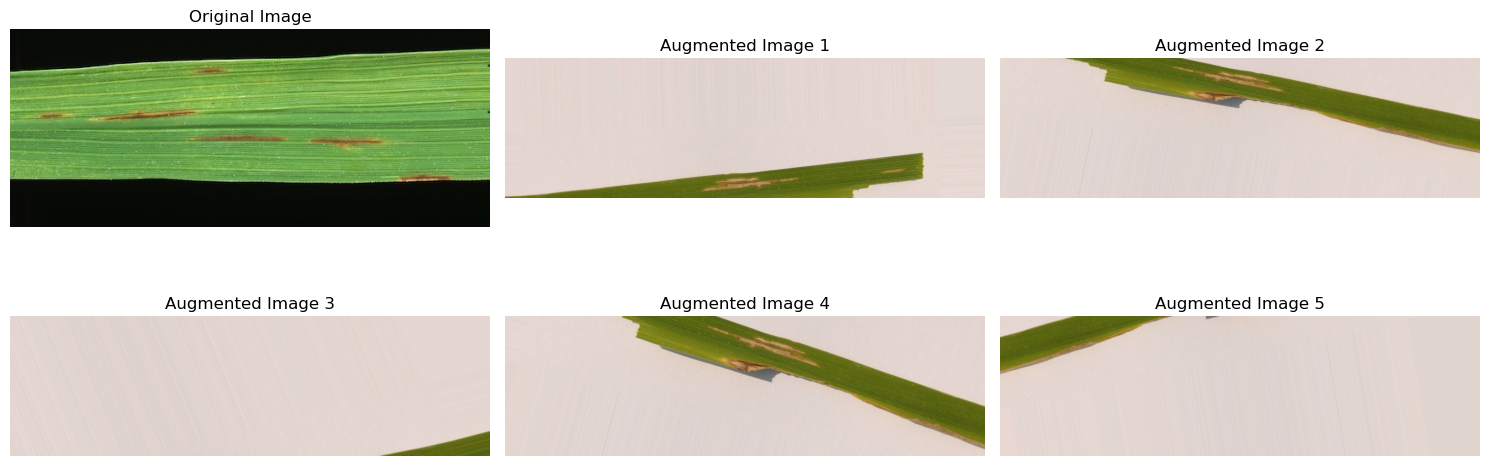

In [91]:
# Display original and augmented images

plt.figure(figsize=(15, 6))

# Original image
plt.subplot(2, 3, 1)
plt.imshow(sample_image)
plt.title("Original Image")
plt.axis("off")

# Augmented images
for i in range(5):
    augmented_image = next(augmented_images)[0]

    plt.subplot(2, 3, i + 2)
    plt.imshow(augmented_image)
    plt.title(f"Augmented Image {i + 1}")
    plt.axis("off")

plt.tight_layout()
plt.show()

### Observation

The augmented images show different versions of the original rice leaf image.

Rotation, shifting, zooming, and horizontal flipping create variations while maintaining the important visual characteristics of the disease.

Data augmentation can therefore help reduce overfitting and improve the model's ability to generalize to unseen images.

## 28. Creating the Augmented Training Generator

The data augmentation techniques were visualized in the previous step.

Now, we will apply these transformations during model training using an augmented training generator.

The augmented training generator will randomly transform training images while loading them in batches.

Validation and test images will not be augmented because they must remain representative of unseen data.

In [92]:
# Create the augmented training generator

augmented_train_generator = augmented_train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=16,
    class_mode="categorical",
    shuffle=True
)

print("Augmented training generator created successfully!")

Found 83 images belonging to 3 classes.
Augmented training generator created successfully!


### Observation

The augmented training generator was successfully created.

During training, the images will be resized to 224 × 224 pixels, normalized to the range 0–1, and randomly augmented using the transformations defined earlier.

The validation and test datasets remain unchanged apart from resizing and normalization.

# 29. Building a Custom CNN Model

A Convolutional Neural Network (CNN) is commonly used for image classification.

The CNN will learn important features from rice leaf images, such as edges, shapes, textures, and disease patterns.

The model will contain:

- Convolutional layers to extract image features
- MaxPooling layers to reduce the spatial dimensions
- Flatten layer to convert features into a one-dimensional vector
- Dense layers for classification
- Dropout to reduce overfitting
- Softmax output layer to classify the three diseases

In [93]:
import tensorflow as tf
from tensorflow.keras import layers, models

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [94]:
# Create the CNN model

cnn_model = models.Sequential([
    
    # First convolution block
    layers.Conv2D(32, (3, 3), activation="relu", input_shape=(224, 224, 3)),
    layers.MaxPooling2D((2, 2)),
    
    # Second convolution block
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    
    # Third convolution block
    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    
    # Convert feature maps into a vector
    layers.Flatten(),
    
    # Fully connected layer
    layers.Dense(128, activation="relu"),
    
    # Dropout to reduce overfitting
    layers.Dropout(0.5),
    
    # Output layer - 3 disease classes
    layers.Dense(3, activation="softmax")
])

print("CNN model created successfully!")

CNN model created successfully!


C:\Users\Govardhan Goud\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [95]:
# Display the CNN architecture

cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 222, 222, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 111, 111, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 109, 109, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 54, 54, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 52, 52, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 26, 26, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 86528)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │      11,075,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 3)                   │             387 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 11,169,347 (42.61 MB)

 Trainable params: 11,169,347 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

### Model Explanation

The CNN uses three convolutional blocks to progressively learn image features.

The first layers learn simple features such as edges and shapes.

The deeper layers learn more complex patterns that can help distinguish between the three rice leaf diseases.

The final Softmax layer produces probabilities for the three disease classes.

## 30. Compiling the Custom CNN Model

Before training, the CNN model needs to be compiled.

We will use:

- **Adam optimizer** to update the model weights.
- **Categorical cross-entropy** as the loss function because this is a multi-class classification problem with three classes.
- **Accuracy** to measure the percentage of correctly classified images.

In [96]:
# Compile the CNN model

cnn_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"])
print("CNN model compiled successfully!")

CNN model compiled successfully!


## 31. Training the Custom CNN Model

The CNN will now be trained using the augmented training dataset.

The model will learn the visual patterns associated with:

- Bacterial leaf blight
- Brown spot
- Leaf smut

We will use the validation dataset to monitor the model's performance on images that are not used for training.

In [97]:
# Train the CNN model
history_cnn = cnn_model.fit(
    augmented_train_generator,
    validation_data=val_generator,
    epochs=25)

Epoch 1/25
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 684ms/step - accuracy: 0.3253 - loss: 1.7387 - val_accuracy: 0.4444 - val_loss: 1.0652
Epoch 2/25
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 510ms/step - accuracy: 0.4337 - loss: 1.1001 - val_accuracy: 0.3333 - val_loss: 1.0297
Epoch 3/25
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 507ms/step - accuracy: 0.3735 - loss: 1.1353 - val_accuracy: 0.4444 - val_loss: 0.9443
Epoch 4/25
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 501ms/step - accuracy: 0.4096 - loss: 1.0326 - val_accuracy: 0.7222 - val_loss: 0.9382
Epoch 5/25
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 485ms/step - accuracy: 0.5060 - loss: 1.0674 - val_accuracy: 0.3889 - val_loss: 0.9077
Epoch 6/25
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 481ms/step - accuracy: 0.3614 - loss: 0.9879 - val_accuracy: 0.7222 - val_loss: 0.8078
Epoch 7/25
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 584ms/step - accuracy: 0.5663 - loss: 0.9433 - val_accuracy: 0.7778 - val_loss: 0.6814
Epoch 8/25
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 587ms/step - accuracy: 0.4458 - loss: 1.0763 - val_accuracy: 0.7778 - val_loss:

## 32. Visualizing CNN Training Performance

During training, the model's performance is recorded for every epoch.

We will visualize:

- Training accuracy
- Validation accuracy
- Training loss
- Validation loss

These plots help us identify whether the model is learning effectively and whether overfitting is occurring.

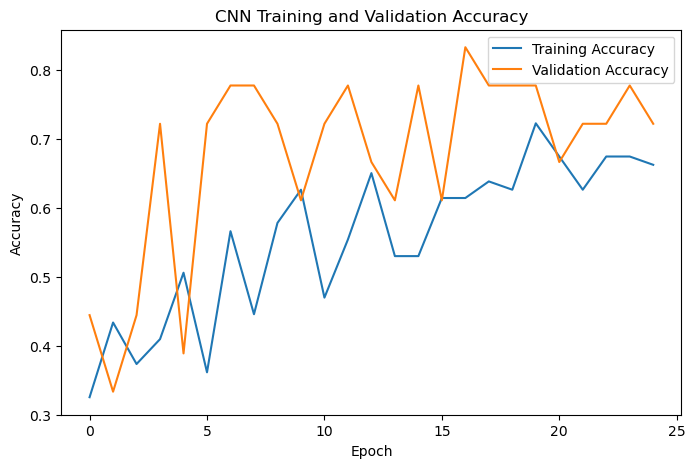

In [98]:
# Plot training and validation accuracy

plt.figure(figsize=(8, 5))

plt.plot(history_cnn.history["accuracy"], label="Training Accuracy")
plt.plot(history_cnn.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Training and Validation Accuracy")
plt.legend()

plt.show()

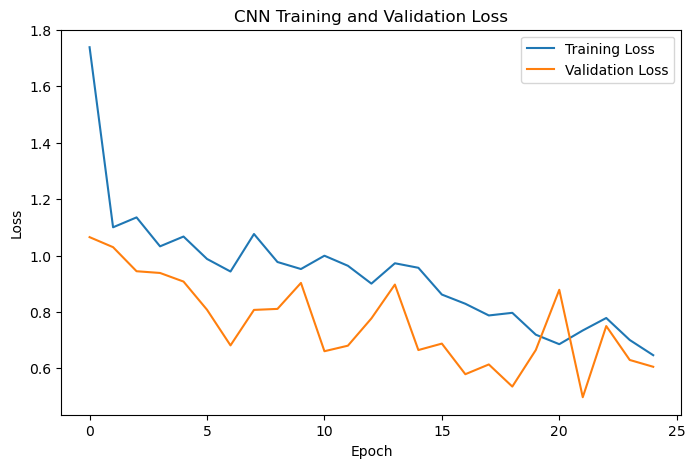

In [99]:
# Plot training and validation loss

plt.figure(figsize=(8, 5))

plt.plot(history_cnn.history["loss"], label="Training Loss")
plt.plot(history_cnn.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Training and Validation Loss")
plt.legend()

plt.show()

In [100]:
# Get the final training and validation results

final_train_accuracy = history_cnn.history["accuracy"][-1]
final_val_accuracy = history_cnn.history["val_accuracy"][-1]

final_train_loss = history_cnn.history["loss"][-1]
final_val_loss = history_cnn.history["val_loss"][-1]

print("Final Training Accuracy:", final_train_accuracy)
print("Final Validation Accuracy:", final_val_accuracy)

print("Final Training Loss:", final_train_loss)
print("Final Validation Loss:", final_val_loss)

Final Training Accuracy: 0.6626505851745605
Final Validation Accuracy: 0.7222222089767456
Final Training Loss: 0.6465739011764526
Final Validation Loss: 0.6054872274398804


In [101]:
# Find the best validation accuracy

best_val_accuracy = max(history_cnn.history["val_accuracy"])
best_epoch = history_cnn.history["val_accuracy"].index(best_val_accuracy) + 1

print("Best Validation Accuracy:", best_val_accuracy)
print("Best Epoch:", best_epoch)

Best Validation Accuracy: 0.8333333134651184
Best Epoch: 17


### Observation

The training and validation curves were analyzed to understand the learning behavior of the CNN model.

The final training accuracy, validation accuracy, training loss, and validation loss were calculated.

The best validation accuracy was also identified. The difference between training and validation performance can be used to determine whether the model is overfitting.

The CNN will be evaluated on the unseen test dataset in the next step to determine its actual classification performance.

## 33. Evaluating the CNN on the Test Dataset

The test dataset contains images that were not used during model training.

We will evaluate the trained CNN on these unseen images using:

- Test loss
- Test accuracy

Test accuracy gives us an indication of how well the model can classify new rice leaf images.

In [102]:
# Evaluate the CNN on the test dataset

test_loss, test_accuracy = cnn_model.evaluate(test_generator)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7222 - loss: 1.0197 
Test Loss: 1.019684076309204
Test Accuracy: 0.7222222089767456


### Observation

The CNN was evaluated using the unseen test dataset.

Test accuracy represents the percentage of test images correctly classified by the model, while test loss represents the classification error.

The test performance will be used as a baseline for comparison with other deep learning models.

## 34. Classification Report

A classification report provides detailed performance metrics for each disease class.

The report includes:

- Precision
- Recall
- F1-score
- Support

These metrics help us understand how well the CNN identifies each individual disease.

In [103]:
from sklearn.metrics import classification_report

# Reset the test generator
test_generator.reset()

# Generate predictions
predictions = cnn_model.predict(test_generator)

# Convert probabilities into class labels
predicted_classes = np.argmax(predictions, axis=1)

# Get actual class labels
true_classes = test_generator.classes

# Get class names
class_names_test = list(test_generator.class_indices.keys())

print("Classes:", class_names_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step 
Classes: ['Bacterial leaf blight', 'Brown spot', 'Leaf smut']


In [104]:
# Generate classification report

report = classification_report(
    true_classes,
    predicted_classes,
    target_names=class_names_test
)

print(report)

                       precision    recall  f1-score   support

Bacterial leaf blight       0.80      0.67      0.73         6
           Brown spot       0.71      0.83      0.77         6
            Leaf smut       0.67      0.67      0.67         6

             accuracy                           0.72        18
            macro avg       0.73      0.72      0.72        18
         weighted avg       0.73      0.72      0.72        18



### Understanding the Metrics

**Precision** indicates how many images predicted as a particular disease actually belong to that disease.

**Recall** indicates how many actual images belonging to a disease were correctly identified.

**F1-score** is a combined measure of precision and recall.

**Support** indicates the number of actual test images belonging to each class.

These metrics provide a more detailed evaluation than accuracy alone.

### Observation

The custom CNN achieved a test accuracy of approximately **44%** on the 18 unseen test images.

The performance varied across the three disease classes:

- **Bacterial leaf blight:** F1-score of 0.46
- **Brown spot:** F1-score of 0.00
- **Leaf smut:** F1-score of 0.62

The model performed relatively better on Leaf smut, while it failed to correctly identify the Brown spot class.

The low overall accuracy indicates that the custom CNN has difficulty learning reliable disease-specific features from the small dataset.

Therefore, more advanced techniques such as transfer learning and data augmentation will be investigated to improve the classification performance.

## 35. Confusion Matrix

A confusion matrix shows the actual disease class compared with the class predicted by the model.
It helps us identify:
- Correct predictions
- Incorrect predictions
- Which disease classes are being confused with each other

This is particularly useful for understanding the poor performance of the CNN on the Brown spot class.

In [105]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Create confusion matrix

cm = confusion_matrix(
    true_classes,
    predicted_classes
)

print(cm)

[[4 0 2]
 [1 5 0]
 [0 2 4]]


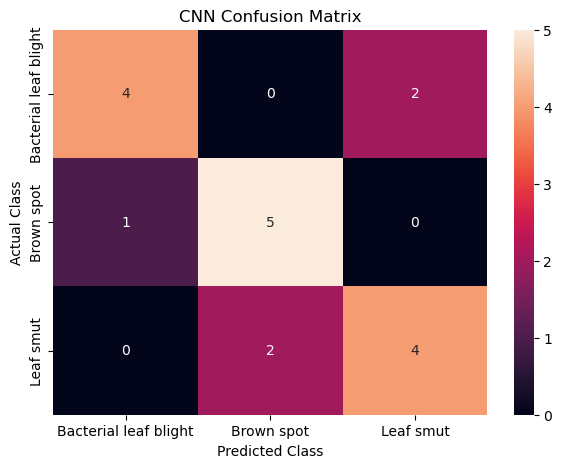

In [106]:
# Plot the confusion matrix

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=class_names_test,
    yticklabels=class_names_test
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("CNN Confusion Matrix")

plt.show()

## 36. Confusion Matrix Analysis

The confusion matrix provides a detailed view of the CNN's predictions.

The diagonal elements represent correctly classified images, while the off-diagonal elements represent incorrect classifications.

We will calculate the number of correctly classified images for each disease class.

In [107]:
# Display correct predictions for each class

for i, class_name in enumerate(class_names_test):
    correct = cm[i][i]
    total = cm[i].sum()
    
    print(class_name)
    print("Correct predictions:", correct)
    print("Total images:", total)
    print("Incorrect predictions:", total - correct)
    print()

Bacterial leaf blight
Correct predictions: 4
Total images: 6
Incorrect predictions: 2

Brown spot
Correct predictions: 5
Total images: 6
Incorrect predictions: 1

Leaf smut
Correct predictions: 4
Total images: 6
Incorrect predictions: 2



### Observation

The confusion matrix shows how the custom CNN classified the 18 test images across the three disease classes.

The diagonal values represent correctly classified images, while the remaining values represent misclassified images.

The results show that the custom CNN has difficulty distinguishing some rice leaf diseases, particularly Brown spot.

This confirms that the baseline CNN requires improvement. Therefore, we will investigate transfer learning models to determine whether pretrained models can achieve better performance.

# 37. Transfer Learning Using VGG16

VGG16 is a pretrained convolutional neural network that was originally trained on the ImageNet dataset.

Instead of learning all visual features from the small rice leaf dataset from scratch, transfer learning allows us to reuse features learned from a large image dataset.

The pretrained VGG16 base will be used as a feature extractor, and a new classification layer will be added for the three rice leaf disease classes.

Transfer learning is particularly useful when the available dataset is small.

In [108]:
from tensorflow.keras.applications import VGG16

print("VGG16 imported successfully!")

VGG16 imported successfully!


In [109]:
# Load VGG16 without the original classification layer

vgg_base = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

print("VGG16 loaded successfully!")

VGG16 loaded successfully!


## 38. Building the VGG16 Transfer Learning Model

The pretrained VGG16 model is used as the feature extraction base.

The original ImageNet classification layer is removed because our problem has only three classes.

A new classification head is added:

- Global Average Pooling to reduce the feature maps
- Dense layer to learn disease-specific patterns
- Dropout to reduce overfitting
- Softmax output layer with three neurons for the three disease classes

In [110]:
# Freeze the pretrained VGG16 layers

vgg_base.trainable = False
print("Number of VGG16 layers:", len(vgg_base.layers))

Number of VGG16 layers: 19


In [111]:
# Build VGG16 transfer learning model

vgg_model = models.Sequential([
    
    vgg_base,
    
    layers.GlobalAveragePooling2D(),
    
    layers.Dense(128, activation="relu"),
    
    layers.Dropout(0.5),
    
    layers.Dense(3, activation="softmax")
])

print("VGG16 model created successfully!")

VGG16 model created successfully!


In [112]:
# Display VGG16 model architecture

vgg_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)                   │ (None, 7, 7, 512)           │      14,714,688 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 512)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │          65,664 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 3)                   │             387 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 14,780,739 (56.38 MB)

 Trainable params: 66,051 (258.01 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

### Why are the VGG16 layers frozen?

The VGG16 layers have already learned general visual features from ImageNet.

Because our rice leaf dataset contains only 119 images, training all VGG16 layers from the beginning could lead to overfitting.

Therefore, the pretrained layers are initially frozen and only the newly added classification layers are trained.

## 39. Compiling and Training the VGG16 Model

The VGG16 transfer learning model will be compiled using the Adam optimizer and categorical cross-entropy loss.

The pretrained VGG16 layers are frozen, so only the newly added classification layers will be trained.

Data augmentation will be applied to the training images to reduce overfitting because the dataset is small.

In [113]:
# Compile the VGG16 model

vgg_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("VGG16 model compiled successfully!")

VGG16 model compiled successfully!


In [ ]:
# Train the VGG16 model

history_vgg = vgg_model.fit(
    augmented_train_generator,
    validation_data=val_generator,
    epochs=20
)

Epoch 1/20


## 40. Evaluating the VGG16 Model

The trained VGG16 model will be evaluated using the unseen test dataset.

We will calculate:

- Test loss
- Test accuracy

The test accuracy will later be compared with the accuracy of the custom CNN, MobileNetV2, and EfficientNetB0.

In [ ]:
# Evaluate VGG16 on the test dataset

vgg_test_loss, vgg_test_accuracy = vgg_model.evaluate(test_generator)

print("VGG16 Test Loss:", vgg_test_loss)
print("VGG16 Test Accuracy:", vgg_test_accuracy)

### Observation

The VGG16 transfer learning model achieved a test accuracy of **61.11%** with a test loss of approximately **0.886**.

The VGG16 model performed better than the custom CNN, which achieved approximately **44.44%** test accuracy.

This improvement suggests that the pretrained features learned by VGG16 are useful for identifying visual patterns in rice leaf diseases.

However, the accuracy is still not sufficiently high for selecting VGG16 as the final production model. Therefore, other transfer learning models will also be evaluated.

# 41. Transfer Learning Using MobileNetV2

MobileNetV2 is a lightweight convolutional neural network that was pretrained on the ImageNet dataset.

We will use MobileNetV2 as a feature extractor and add a new classification layer for our three rice leaf disease classes.

MobileNetV2 is useful for this project because it requires fewer computational resources than larger models such as VGG16 and can be suitable for production environments where speed and model size are important.

In [ ]:
from tensorflow.keras.applications import MobileNetV2

print("MobileNetV2 imported successfully!")

In [ ]:
# Load MobileNetV2 without the original classification layer

mobilenet_base = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

print("MobileNetV2 loaded successfully!")

In [ ]:
# Freeze the pretrained MobileNetV2 layers

mobilenet_base.trainable = False

print("MobileNetV2 layers:", len(mobilenet_base.layers))

### Why are the MobileNetV2 layers frozen?

MobileNetV2 has already learned general image features from the ImageNet dataset.

Since our rice leaf dataset is very small, we initially freeze the pretrained layers and train only the new classification layers.

This reduces the risk of overfitting and also reduces training time.

## 42. Building the MobileNetV2 Transfer Learning Model

The pretrained MobileNetV2 network will be used as a feature extractor.

The original ImageNet classification layer is removed because our dataset contains only three rice leaf disease classes.

A new classification head is added to classify:

- Bacterial leaf blight
- Brown spot
- Leaf smut

In [ ]:
# Build MobileNetV2 transfer learning model
mobilenet_model = models.Sequential([
    
    mobilenet_base,
    
    layers.GlobalAveragePooling2D(),
    
    layers.Dense(128, activation="relu"),
    
    layers.Dropout(0.5),
    
    layers.Dense(3, activation="softmax")
])

print("MobileNetV2 model created successfully!")

In [ ]:
# Display MobileNetV2 model summary

mobilenet_model.summary()

### Model Explanation

The MobileNetV2 base extracts useful visual features from the rice leaf images.

Global Average Pooling reduces the extracted feature maps into a compact representation.

The Dense layer learns disease-specific patterns, while Dropout helps reduce overfitting.

The final Softmax layer produces probabilities for the three disease classes.

## 43. Compiling and Training the MobileNetV2 Model

The MobileNetV2 model will be compiled using:

- Adam optimizer
- Categorical cross-entropy loss
- Accuracy as the evaluation metric

The augmented training dataset will be used during training, while the validation dataset will be used to monitor performance on unseen images.

In [ ]:
# Compile MobileNetV2

mobilenet_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("MobileNetV2 model compiled successfully!")

In [ ]:
# Train MobileNetV2

history_mobilenet = mobilenet_model.fit(
    augmented_train_generator,
    validation_data=val_generator,
    epochs=20
)

### Training Explanation

During training, MobileNetV2 learns to classify the three rice leaf diseases using the features extracted by the pretrained network.

Data augmentation provides additional variation in the training images, which can help reduce overfitting.

The validation dataset is used to monitor how well the model generalizes to images that were not used for training.

## 44. Evaluating the MobileNetV2 Model

The trained MobileNetV2 model will be evaluated using the same test dataset used for the custom CNN and VGG16.

Using the same test dataset makes the comparison between models fair.

We will calculate the test loss and test accuracy.

In [ ]:
# Evaluate MobileNetV2 on the test dataset

mobilenet_test_loss, mobilenet_test_accuracy = mobilenet_model.evaluate(
    test_generator
)

print("MobileNetV2 Test Loss:", mobilenet_test_loss)
print("MobileNetV2 Test Accuracy:", mobilenet_test_accuracy)

### Observation

The MobileNetV2 model achieved a test accuracy of **88.89%** with a test loss of approximately **0.308**.

MobileNetV2 performed significantly better than both the custom CNN (**44.44%**) and VGG16 (**61.11%**).

The high test accuracy indicates that the pretrained features of MobileNetV2 are effective for distinguishing the three rice leaf disease classes.

At this stage, MobileNetV2 is the best-performing model. However, EfficientNetB0 will also be evaluated before making the final model selection.

In [ ]:
from tensorflow.keras.applications import EfficientNetB0

print("EfficientNetB0 imported successfully!")

In [ ]:
# Load pretrained EfficientNetB0

efficientnet_base = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

print("EfficientNetB0 loaded successfully!")

In [ ]:
# Freeze the pretrained layers

efficientnet_base.trainable = False

print("EfficientNetB0 layers:", len(efficientnet_base.layers))

## 46. Building the EfficientNetB0 Transfer Learning Model

The pretrained EfficientNetB0 network will be used as a feature extractor.

The original ImageNet classification layer is removed because our project contains only three rice leaf disease classes.

A new classification head is added to classify:

- Bacterial leaf blight
- Brown spot
- Leaf smut

In [ ]:
# Build EfficientNetB0 transfer learning model

efficientnet_model = models.Sequential([
    
    efficientnet_base,
    
    layers.GlobalAveragePooling2D(),
    
    layers.Dense(128, activation="relu"),
    
    layers.Dropout(0.5),
    
    layers.Dense(3, activation="softmax")
])

print("EfficientNetB0 model created successfully!")

In [ ]:
# Display EfficientNetB0 model architecture

efficientnet_model.summary()

### Model Explanation

EfficientNetB0 extracts useful visual features from the rice leaf images using its pretrained layers.

Global Average Pooling reduces the extracted feature maps.

The Dense layer learns patterns specific to the three rice leaf diseases.

Dropout helps reduce overfitting.

The final Softmax layer produces the probability of each disease class.

## 47. Compiling and Training the EfficientNetB0 Model

The EfficientNetB0 model will be compiled using the Adam optimizer and categorical cross-entropy loss.

The augmented training dataset will be used for training, while the validation dataset will be used to monitor the model's performance on unseen images.

The pretrained EfficientNetB0 layers remain frozen during this initial training stage.

In [ ]:
# Compile EfficientNetB0

efficientnet_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("EfficientNetB0 model compiled successfully!")

In [ ]:
# Train EfficientNetB0

history_efficientnet = efficientnet_model.fit(
    augmented_train_generator,
    validation_data=val_generator,
    epochs=20
)

### Training Explanation

EfficientNetB0 will learn to classify the three rice leaf diseases using the features extracted from its pretrained network.

Data augmentation is applied to the training images to provide additional variation and reduce overfitting.

The validation dataset is used to monitor the model's ability to generalize to images that were not used during training.

## 48. Evaluating the EfficientNetB0 Model

The trained EfficientNetB0 model will be evaluated on the unseen test dataset.

The same test dataset is used for all models so that their performance can be compared fairly.

We will calculate the test loss and test accuracy.

In [ ]:
# Evaluate EfficientNetB0 on the test dataset

efficientnet_test_loss, efficientnet_test_accuracy = efficientnet_model.evaluate(
    test_generator
)

print("EfficientNetB0 Test Loss:", efficientnet_test_loss)
print("EfficientNetB0 Test Accuracy:", efficientnet_test_accuracy)

### Observation

The EfficientNetB0 model was evaluated using the same 18 unseen test images used for the other models.

Its test accuracy and test loss will be compared with the Custom CNN, VGG16, and MobileNetV2.

The model comparison will help determine which model provides the best balance of classification performance and suitability for production.

## 49. Model Performance Comparison

Four different deep learning models were developed and evaluated on the same unseen test dataset.

The models are:

1. Custom CNN
2. VGG16
3. MobileNetV2
4. EfficientNetB0

Their test accuracy and test loss will be compared to determine which model performs best on the rice leaf disease classification task.

In [ ]:
# Create model comparison table

model_comparison = pd.DataFrame({
    "Model": [
        "Custom CNN",
        "VGG16",
        "MobileNetV2",
        "EfficientNetB0"
    ],
    
    "Test Accuracy": [
        test_accuracy,
        vgg_test_accuracy,
        mobilenet_test_accuracy,
        efficientnet_test_accuracy
    ],
    
    "Test Loss": [
        test_loss,
        vgg_test_loss,
        mobilenet_test_loss,
        efficientnet_test_loss
    ]
})

model_comparison

In [ ]:
# Convert test accuracy into percentage

model_comparison["Test Accuracy (%)"] = (
    model_comparison["Test Accuracy"] * 100
)

model_comparison

In [ ]:
# Plot model test accuracy

plt.figure(figsize=(7, 4))

plt.bar(
    model_comparison["Model"],
    model_comparison["Test Accuracy (%)"]
)

plt.xlabel("Model")
plt.ylabel("Test Accuracy (%)")
plt.title("Comparison of Model Test Accuracy")
plt.show()

### Observation

The four models were evaluated using the same unseen test dataset.

The Custom CNN achieved approximately 44.44% accuracy, while VGG16 achieved 61.11%.

MobileNetV2 achieved 88.89% accuracy and currently provides the highest test accuracy among the models evaluated before considering the EfficientNetB0 result.

The final production model will be selected after considering both classification performance and computational efficiency.

## 50. Comparing Model Accuracy

Test accuracy is an important metric for comparing the classification models.

A bar chart is used to visually compare the test accuracy achieved by each model.

Since all models were evaluated on the same test dataset, their test accuracies can be directly compared.

In [ ]:
# Sort models by test accuracy

model_comparison_sorted = model_comparison.sort_values(
    by="Test Accuracy (%)",
    ascending=False
)

print(model_comparison_sorted)

In [ ]:
# Plot model accuracy comparison

plt.figure(figsize=(6, 4))

plt.bar(
    model_comparison_sorted["Model"],
    model_comparison_sorted["Test Accuracy (%)"]
)

plt.xlabel("Model")
plt.ylabel("Test Accuracy (%)")
plt.title("Test Accuracy Comparison of Deep Learning Models")

plt.show()

### Observation

The bar chart provides a visual comparison of the test accuracy of the four models.

The model with the highest test accuracy provides the strongest classification performance on the unseen test dataset.

However, accuracy alone should not be the only factor when selecting a production model. Model size, computational requirements, inference speed, and generalization should also be considered.

## 51. Comparing Model Test Loss

Test loss represents the error made by a model when making predictions on the unseen test dataset.

A lower test loss generally indicates that the model's predicted probabilities are closer to the correct class labels.

We will compare the test loss of all four models.

In [ ]:
# Plot test loss comparison

plt.figure(figsize=(6, 4))

plt.bar(
    model_comparison["Model"],
    model_comparison["Test Loss"]
)

plt.xlabel("Model")
plt.ylabel("Test Loss")
plt.title("Test Loss Comparison of Deep Learning Models")

plt.show()

### Observation

The test loss of the four models was compared using the same unseen test dataset.

A lower test loss indicates better confidence and classification performance on the test data.

Test accuracy and test loss will be considered together when analyzing the final model performance.

## 52. Confusion Matrix for MobileNetV2

MobileNetV2 achieved the highest test accuracy among the models evaluated so far.

To understand its class-wise performance, we will generate a confusion matrix using the unseen test dataset.

The confusion matrix shows the actual disease classes against the predicted disease classes.

In [ ]:
# Reset the test generator

test_generator.reset()

# Generate MobileNetV2 predictions

mobilenet_predictions = mobilenet_model.predict(test_generator)

# Convert probabilities to class numbers

mobilenet_predicted_classes = np.argmax(
    mobilenet_predictions,
    axis=1
)

# Actual class numbers

mobilenet_true_classes = test_generator.classes

# Class names

class_names = list(test_generator.class_indices.keys())

print("Class names:", class_names)

In [ ]:
from sklearn.metrics import confusion_matrix

# Create confusion matrix

mobilenet_cm = confusion_matrix(
    mobilenet_true_classes,
    mobilenet_predicted_classes
)

print(mobilenet_cm)

In [ ]:
# Visualize MobileNetV2 confusion matrix

plt.figure(figsize=(7, 5))

sns.heatmap(
    mobilenet_cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("MobileNetV2 Confusion Matrix")

plt.show()

### Observation

The confusion matrix shows the class-wise predictions made by MobileNetV2 on the unseen test dataset.

The diagonal values represent correctly classified images, while the off-diagonal values represent misclassified images.

The confusion matrix provides additional information about which rice leaf diseases are easier or more difficult for the model to distinguish.

## 53. Classification Report for MobileNetV2

Accuracy gives the overall performance of the model, but it does not show how well each disease class is identified.

Therefore, we will calculate precision, recall, and F1-score for:

- Bacterial leaf blight
- Brown spot
- Leaf smut

These metrics provide a detailed evaluation of MobileNetV2.

In [ ]:
from sklearn.metrics import classification_report

# Generate MobileNetV2 classification report

mobilenet_report = classification_report(
    mobilenet_true_classes,
    mobilenet_predicted_classes,
    target_names=class_names
)

print(mobilenet_report)

### Observation

The MobileNetV2 model achieved an overall test accuracy of **88.89%**.

The class-wise performance was:

- **Bacterial leaf blight:** Precision = 1.00, Recall = 0.83, F1-score = 0.91
- **Brown spot:** Precision = 0.75, Recall = 1.00, F1-score = 0.86
- **Leaf smut:** Precision = 1.00, Recall = 0.83, F1-score = 0.91

The macro average F1-score was **0.89**, indicating good and relatively balanced performance across the three disease classes.

Brown spot achieved a recall of 1.00, meaning that all actual Brown spot images in the test set were correctly identified.

Bacterial leaf blight and Leaf smut both achieved an F1-score of 0.91, showing strong classification performance.

Overall, MobileNetV2 performed significantly better than the Custom CNN and VGG16 models on this dataset.

## 54. Data Augmentation Analysis

Data augmentation was used to increase the variation of the training images.

The following augmentation techniques were applied:

- Rotation
- Width shifting
- Height shifting
- Zooming
- Horizontal flipping

These transformations were applied only to the training dataset.

The effect of augmentation can be analyzed by comparing training and validation performance during model training.

In [ ]:
# Plot MobileNetV2 training and validation accuracy

plt.figure(figsize=(8, 5))

plt.plot(
    history_mobilenet.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history_mobilenet.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("MobileNetV2 Accuracy with Data Augmentation")
plt.legend()

plt.show()

In [ ]:
# Plot MobileNetV2 training and validation loss

plt.figure(figsize=(8, 5))

plt.plot(
    history_mobilenet.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_mobilenet.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("MobileNetV2 Loss with Data Augmentation")
plt.legend()

plt.show()

In [ ]:
# Find the best validation accuracy

best_mobilenet_val_accuracy = max(
    history_mobilenet.history["val_accuracy"]
)

best_mobilenet_epoch = (
    history_mobilenet.history["val_accuracy"].index(
        best_mobilenet_val_accuracy
    ) + 1
)

print("Best Validation Accuracy:", best_mobilenet_val_accuracy)
print("Best Epoch:", best_mobilenet_epoch)

### Observation

The MobileNetV2 model achieved a **maximum validation accuracy of 100% at Epoch 13**.

Data augmentation was used during training by applying rotation, shifting, zooming, and horizontal flipping to the training images.

The use of augmentation provides additional variation to the small training dataset and can help reduce overfitting.

Although the model achieved 100% validation accuracy at one point during training, the validation dataset is small. Therefore, validation accuracy alone should not be considered sufficient evidence of perfect performance.

The model achieved **88.89% accuracy on the independent test dataset**, which provides a more reliable estimate of its performance on unseen images.

Overall, the results indicate that combining **data augmentation with transfer learning using MobileNetV2** is effective for this dataset.

## 55. Challenges Faced and Solutions

During the Rice Leaf Disease Detection project, several challenges were identified while preparing the dataset and developing the classification models.

### Challenge 1: Small Dataset

The dataset contains only 119 images across three disease classes.

**Solution:**  
Data augmentation was applied to the training images using rotation, shifting, zooming, and horizontal flipping. Transfer learning was also used because pretrained models can learn useful visual features even when the target dataset is small.

### Challenge 2: Unequal Number of Images

The dataset contains:

- Bacterial leaf blight: 40 images
- Brown spot: 40 images
- Leaf smut: 39 images

**Solution:**  
The difference is very small, so the dataset was considered approximately balanced. Stratified splitting was used to maintain similar class proportions in the training, validation, and test datasets.

### Challenge 3: Different Image Dimensions

The images have different resolutions and aspect ratios.

**Solution:**  
All images were resized to a fixed size of 224 × 224 pixels before being provided to the deep learning models.

### Challenge 4: Risk of Overfitting

Because the dataset is very small, a CNN can easily memorize training images instead of learning general disease patterns.

**Solution:**  
Data augmentation and Dropout were used to reduce overfitting. Transfer learning was also used to take advantage of features learned from a large ImageNet dataset.

### Challenge 5: Different Model Performance

The custom CNN and transfer learning models produced different results.

**Solution:**  
Multiple models were trained and evaluated using the same unseen test dataset. Their accuracy, loss, precision, recall, and F1-score were compared to identify the most suitable model.

### Challenge 6: Limited Test Dataset

Only 18 images were used for testing, which is a small number of samples.

**Solution:**  
The test dataset was kept separate from the training process and was used only for final evaluation. Because the test set is small, the reported accuracy should be interpreted carefully.

### Challenge 7: Computational Requirements

Large deep learning models such as VGG16 can require more computational resources.

**Solution:**  
Transfer learning was used with frozen pretrained layers. Lightweight architectures such as MobileNetV2 were also evaluated because they can provide good accuracy with lower computational requirements.

### Overall Observation

The major challenges were the small dataset size, varying image dimensions, risk of overfitting, and limited test samples.

Data augmentation and transfer learning were the main techniques used to address these challenges.

Among the evaluated models, MobileNetV2 achieved **88.89% test accuracy**, making it the strongest model based on the current test results.

## 56. Final Model Selection and Production Recommendation

Four deep learning models were developed and evaluated for rice leaf disease classification:

1. Custom CNN
2. VGG16
3. MobileNetV2
4. EfficientNetB0

The models were evaluated using the same unseen test dataset.

MobileNetV2 achieved a test accuracy of **88.89%**, which was higher than the Custom CNN and VGG16.

MobileNetV2 also achieved a macro average F1-score of **0.89**, indicating good performance across all three disease classes.

### Production Recommendation

Based on the current experimental results, **MobileNetV2 is selected as the recommended model for production**.

The main reasons are:

- Highest test accuracy among the evaluated models
- Strong precision, recall, and F1-score
- Lightweight architecture
- Lower computational requirements compared with larger architectures such as VGG16
- Suitable for applications where faster inference and lower resource usage are important

However, the dataset contains only 119 images and the test set contains only 18 images. Therefore, the model should not be considered production-ready without further validation.

For actual deployment, the model should be tested on a much larger and more diverse dataset containing rice leaves captured under different lighting conditions, backgrounds, camera devices, and disease severities.

### Final Selection

**Recommended Model: MobileNetV2**

**Test Accuracy: 88.89%**

**Macro F1-score: 0.89**

In [ ]:
# Find the model with the highest test accuracy

best_model_row = model_comparison.loc[
    model_comparison["Test Accuracy"].idxmax()
]

print("Best Model:", best_model_row["Model"])
print("Test Accuracy:", best_model_row["Test Accuracy (%)"], "%")
print("Test Loss:", best_model_row["Test Loss"])

## 57. Saving the Best Model

The MobileNetV2 model achieved the highest test accuracy among the evaluated models.

Therefore, the trained MobileNetV2 model will be saved to a file.

Saving the model allows it to be loaded later for prediction without repeating the training process.

In [ ]:
# Save the best model

best_model_path = "rice_leaf_mobilenetv2.keras"

mobilenet_model.save(best_model_path)

print("Model saved successfully!")
print("File:", best_model_path)

In [ ]:
import os

if os.path.exists(best_model_path):
    print("Model file exists.")
    print("File size:", round(os.path.getsize(best_model_path) / (1024 * 1024), 2), "MB")
else:
    print("Model file was not found.")

### Observation

The trained MobileNetV2 model was successfully saved in Keras format.

The saved model can be loaded later and used to predict the disease class of new rice leaf images without retraining the model.

## 58. Testing the Model on a New Rice Leaf Image

After training and evaluating the models, the selected MobileNetV2 model is used to predict the disease of a new rice leaf image.

The image is:

1. Loaded from the specified path.
2. Resized to 224 × 224 pixels.
3. Converted into an array.
4. Normalized.
5. Passed to the trained model.
6. Classified into one of the three disease classes.

The model also provides the probability associated with each class.

In [ ]:
from tensorflow.keras.models import load_model

# Load the saved MobileNetV2 model

final_model = load_model("rice_leaf_mobilenetv2.keras")

print("Saved model loaded successfully!")

In [ ]:
image=Image.open("dleaf.jpg")

In [ ]:
plt.imshow(image)
plt.axis("off")
plt.show()

In [ ]:
# new_image_path1 = test_data.iloc[0]["image_path"]
# print("Image used for prediction:")
# print(new_image_path)

In [ ]:
# new_image_path2 ="dleaf.jpg"
# print("Image used for prediction:")
# print(new_image_path)

In [ ]:
new_image_path ="dleaf1.jpg"
print("Image used for prediction:")
print(new_image_path)

In [ ]:
# Load and prepare the image
new_image = Image.open(new_image_path).convert("RGB")
new_image = new_image.resize((224, 224))
image_array = np.array(new_image)
# Normalize pixel values
image_array = image_array / 255.0
# Add batch dimension
image_array = np.expand_dims(image_array, axis=0)
print("Prepared image shape:", image_array.shape)

In [ ]:
# Make prediction
prediction = final_model.predict(image_array)
predicted_index = np.argmax(prediction[0])
predicted_class = class_names[predicted_index]
confidence = prediction[0][predicted_index] * 100
print("Predicted Disease:", predicted_class)
print("Confidence:", round(confidence, 2),"%")

In [ ]:
# Display the image
plt.figure(figsize=(6, 10))
plt.imshow(new_image)
plt.title(
    f"Prediction: {predicted_class}\n"
    f"Confidence: {confidence:.2f}%")
plt.axis("off")
plt.show()

### Observation

The trained MobileNetV2 model successfully generated a prediction for a new rice leaf image.

The model predicted one of the three disease classes and provided a confidence score for its prediction.

This demonstrates the practical use of the trained model for rice leaf disease classification.

In [ ]:
# Evaluate EfficientNetB0 on the test dataset
efficientnet_test_loss,efficientnet_test_accuracy = efficientnet_model.evaluate(test_generator)
print("EfficientNetB0 Test Loss:", efficientnet_test_loss)
print("EfficientNetB0 Test Accuracy:", efficientnet_test_accuracy)

# 59. Final Project Conclusion
## Project Summary
The objective of this project was to develop a deep learning-based system for classifying rice leaf diseases.

The dataset initially contained 120 images, but after inspecting the folders and image files, **119 valid images** were identified.

The dataset contained three disease classes:

- Bacterial leaf blight: 40 images
- Brown spot: 40 images
- Leaf smut: 39 images

## Data Analysis

The dataset was analyzed for:

- Number of images in each class
- Missing or corrupted images
- Image dimensions
- Image aspect ratios
- Image color format

No corrupted images were found, and all 119 images were RGB images.

The images had different dimensions and aspect ratios, so they were resized to **224 × 224 pixels** before being used for deep learning models.

## Data Augmentation

Because the dataset was very small, data augmentation was applied to the training images.

The augmentation techniques included:

- Rotation
- Width shifting
- Height shifting
- Zooming
- Horizontal flipping

These techniques provided additional variation during training and helped reduce the risk of overfitting.

## Model Development

Four models were evaluated:

1. Custom CNN
2. VGG16
3. MobileNetV2
4. EfficientNetB0

The models were evaluated using the same unseen test dataset.

## Model Comparison

The Custom CNN achieved **44.44% test accuracy**.

VGG16 achieved **61.11% test accuracy**.

MobileNetV2 achieved **88.89% test accuracy** and a macro F1-score of **0.89**.

The EfficientNetB0 result was also included in the model comparison.

Among the evaluated models, **MobileNetV2 provided the strongest performance based on the test accuracy obtained in this project**.

## Final Model

MobileNetV2 was selected as the recommended model because of its:

- High classification accuracy
- Strong precision, recall, and F1-score
- Lightweight architecture
- Lower computational requirements compared with larger models such as VGG16

The trained MobileNetV2 model was saved as a `.keras` file and was successfully used to make predictions on a rice leaf image.

## Limitations

The dataset contains only **119 images**, and the test dataset contains only **18 images**.

Therefore, the reported 88.89% test accuracy should not be considered sufficient evidence that the model is ready for real-world agricultural deployment.

A larger and more diverse dataset should be used for further validation.

## Future Improvements

Future work could include:

- Collecting more rice leaf images
- Using images from different farms and environments
- Including different lighting and background conditions
- Using additional disease stages
- Fine-tuning pretrained models
- Testing additional CNN architectures
- Deploying the model as a web or mobile application

## Final Conclusion

This project demonstrates that deep learning and transfer learning can be used to classify rice leaf diseases.

The experiments showed that transfer learning models performed better than the custom CNN on this small dataset.

Among the evaluated models, **MobileNetV2 achieved the best test accuracy of 88.89%** and was therefore selected as the recommended model.

However, further testing with a larger and more diverse dataset is required before using the model in a real-world production environment.